# 4-1. 인구현황 데이터 분석
* data/인구현황.csv 를 사용하세요
* 연습문제/인구현황분석.ipynb  코드를 완성하세요.


## 1. 지역별 총인구수 Top5


In [179]:
import pandas as pd

# .csv file 읽어오기
data = pd.read_csv('../data/인구현황.csv')
#print(data.shape)
#print(type(data))
#print(data)

# 컬럼명 확인하기
#print(f'컬럼명 = {data.columns}')
#print(data['행정기관'])
# '행정기관' 컬럼에서 '시' 또는 '도'로 끝나는 항목만 필터링
sido_df = data[data['행정기관'].str.endswith(('시', '도'))]
#print(sido_df['행정기관'])

# 지역별 총인구수 TOP5만 출력
sido_df.loc[:, ['행정기관', '총인구수']].sort_values(['총인구수'], ascending=False).head(5)


,행정기관,총인구수
9,경기도,13694685
1,서울특별시,9331828
2,부산광역시,3266598
16,경상남도,3228380
4,인천광역시,3021010


### 1-1. 지역별 총인구수 plot

Malgun Gothic


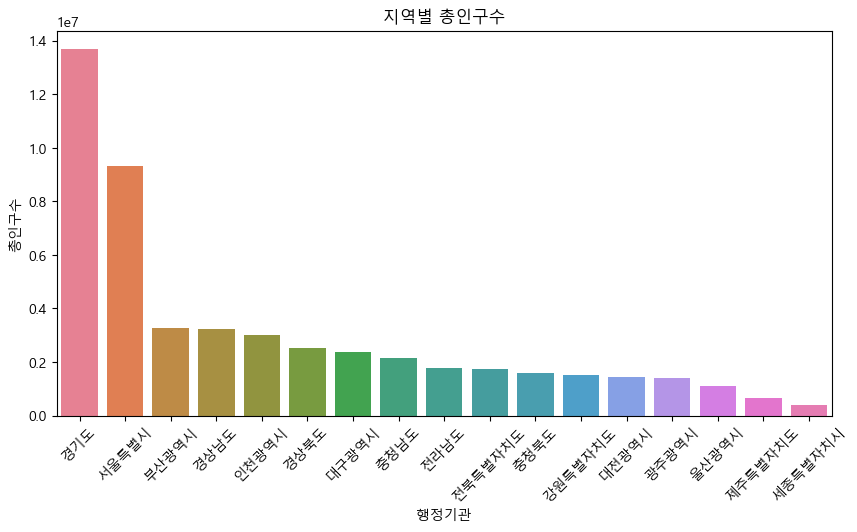

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 폰트 path 설정
[ (font.name, font.fname) for font in fm.fontManager.ttflist if 'Mal' in font.name ]
font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()
print(font_name)
matplotlib.rc('font', family=font_name)

# 지역별 총인구수 내림차순 plot 그리기
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(10,5) 

sido_pop_plot = sns.barplot(x="행정기관", y="총인구수", data=sido_df.sort_values(by='총인구수', ascending=False), ax=axes1, hue='행정기관')
sido_pop_plot.set_title('지역별 총인구수')

# x축 lable 기울이기
for item in axes1.get_xticklabels(): 
    item.set_rotation(45)

plt.show()


## 2. 세대당 인구수 높은 지역 Top5

In [99]:
# 세대당 인구수 TOP5만 출력
sido_df.loc[:, ['행정기관', '세대당 인구']].sort_values(['세대당 인구'], ascending=False)\
    .reset_index(drop=True).head(5)


,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14


### 2-1. 지역별 세대당 인구 Plot

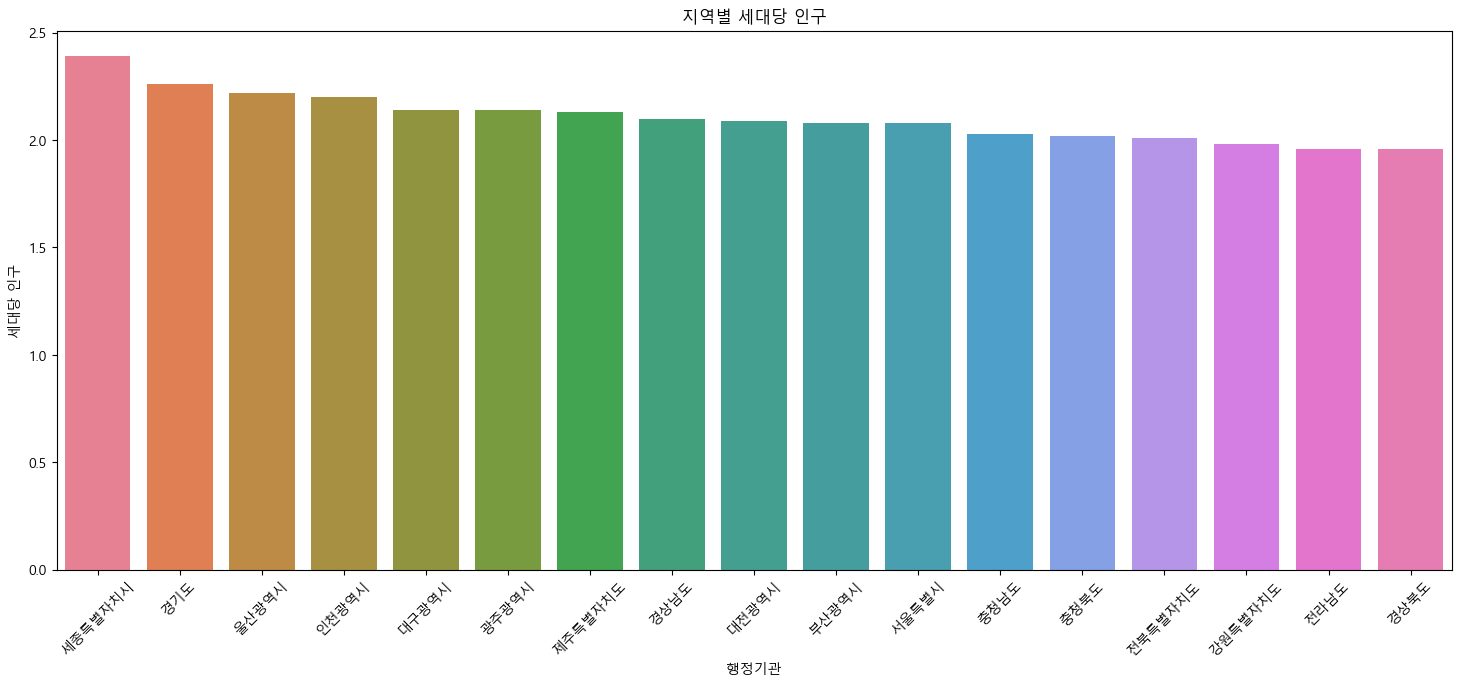

In [183]:
# 지역별 세대당 내림차순 plot 그리기
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(18,7) 

sido_pop_plot = sns.barplot(x="행정기관", y="세대당 인구", data=sido_df.sort_values(by='세대당 인구', ascending=False), ax=axes1, hue='행정기관')
sido_pop_plot.set_title('지역별 세대당 인구')

# x축 lable 기울이기
for item in axes1.get_xticklabels(): 
    item.set_rotation(45)

plt.show()


## 3. 남녀 비율 분석

In [108]:
# 컬럼명 확인하기
print(f'컬럼명 = {data.columns}')
#data.loc[:, ['행정기관','남여 비율']]

# 남여 비율이 높은 순 정렬
sido_df.loc[:, ['행정기관', '남여 비율']].sort_values(['남여 비율'], ascending=False).reset_index(drop=True)

컬럼명 = Index(['행정기관코드', '행정기관', '총인구수', '세대수', '세대당 인구', '남자 인구수', '여자 인구수', '남여 비율'], dtype='object')


,행정기관,남여 비율
0,울산광역시,1.06
1,충청남도,1.05
2,충청북도,1.04
3,경상남도,1.02
4,경상북도,1.02
5,전라남도,1.02
6,경기도,1.01
7,강원특별자치도,1.01
8,제주특별자치도,1.00
9,인천광역시,1.00


### 3-1. 남녀 비율 분석 Plot

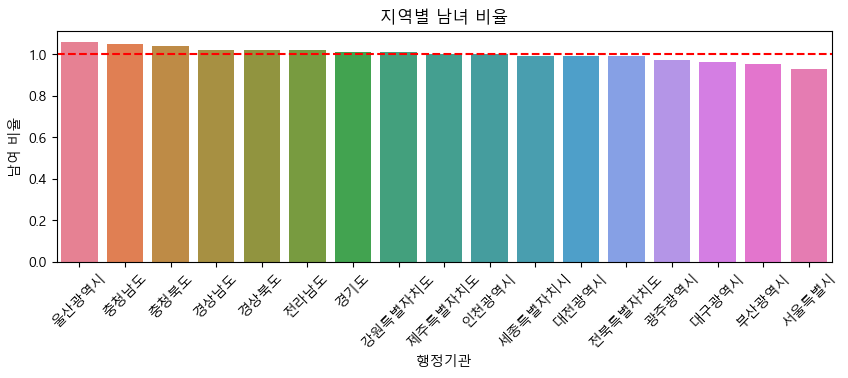

In [114]:
# 남녀 비율 분석 내림차순 plot 그리기
figure, axes1 = plt.subplots(nrows=1, ncols=1)
figure.set_size_inches(10,3) 

sido_pop_plot = sns.barplot(x="행정기관", y="남여 비율", data=sido_df.sort_values(by='남여 비율', ascending=False), ax=axes1, hue='행정기관')
sido_pop_plot.set_title('지역별 남녀 비율')

# x축 lable 기울이기
for item in axes1.get_xticklabels(): 
    item.set_rotation(45)

# axhline() 함수 사용하여 남녀 1:1 비율 기준 빨간선 생성
axes1.axhline(y=1, color='red', linestyle='--', label='남녀 1:1 비율')

plt.show()


## 4. 남자초과 / 여자초과 분석


In [157]:
# ratio_df 데이터프레임 객체에 '남초여초' 라는 새로운 컬럼을 생성, 
# 여초: 남여 비율 1 미만
# 남초: 남여 비율 1 초과
# 동일: 남여 비율 1

ratio_df = pd.DataFrame(sido_df)

# 매게 변수
ratio = ratio_df['남여 비율']

# 분류 함수 정의
def gender_ratio_type(ratio):
    if ratio < 1:
        return '여초'
    elif ratio > 1:
        return '남초'
    else:
        return '동일'

ratio_df['남초여초'] = ratio_df['남여 비율'].apply(gender_ratio_type)
print(ratio_df[['행정기관', '남여 비율', '남초여초']])

       행정기관  남여 비율 남초여초
1     서울특별시   0.93   여초
2     부산광역시   0.95   여초
3     대구광역시   0.96   여초
4     인천광역시   1.00   동일
5     광주광역시   0.97   여초
6     대전광역시   0.99   여초
7     울산광역시   1.06   남초
8   세종특별자치시   0.99   여초
9       경기도   1.01   남초
10  강원특별자치도   1.01   남초
11     충청북도   1.04   남초
12     충청남도   1.05   남초
13  전북특별자치도   0.99   여초
14     전라남도   1.02   남초
15     경상북도   1.02   남초
16     경상남도   1.02   남초
17  제주특별자치도   1.00   동일


## 5. 세대당 인구 평균보다 높은 지역
* 전국 평균 세대당 인구수: 2.11

In [161]:
sido_df.loc[sido_df['세대당 인구'] > sido_df['세대당 인구'].mean(), ['행정기관','세대당 인구']].sort_values(['세대당 인구'], ascending=False).reset_index(drop=True)

,행정기관,세대당 인구
0,세종특별자치시,2.39
1,경기도,2.26
2,울산광역시,2.22
3,인천광역시,2.20
4,대구광역시,2.14
5,광주광역시,2.14
6,제주특별자치도,2.13


### 5-1.   남초 vs 여초 개수 Plot  ( seaborn의 countplot )
###         지역별 세대수 Plot ( seaborn의 barplot )


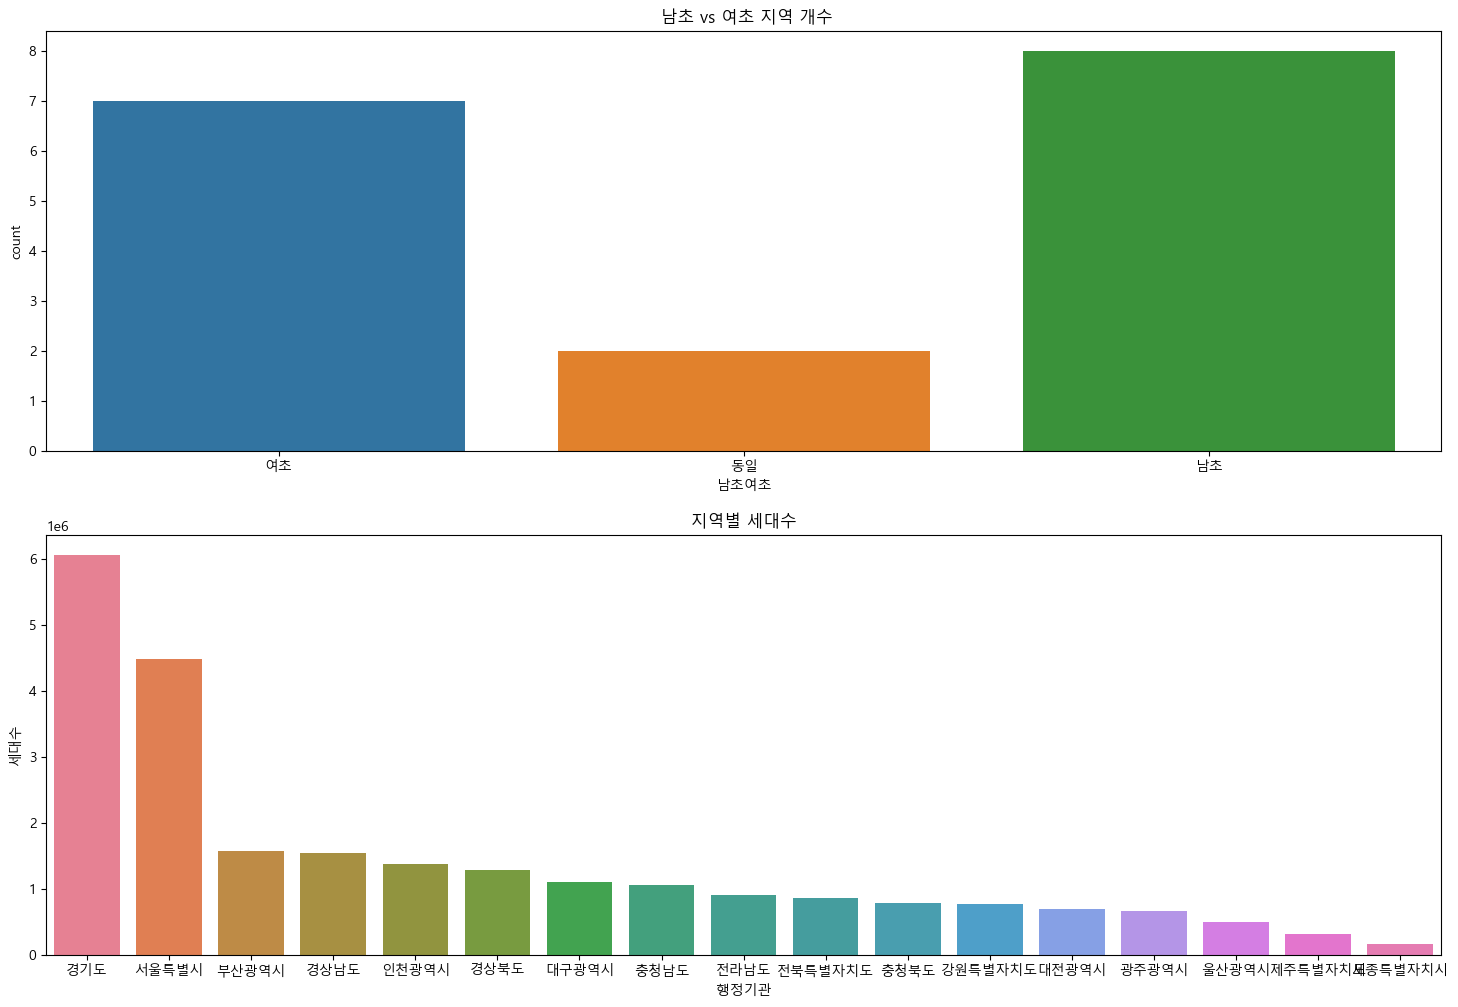

In [178]:
figure,(ax1, ax2) = plt.subplots(nrows=2,ncols=1)
figure.set_size_inches(18,12)

# 남초 vs 여초 개수 Plot ( seaborn의 countplot )
gender_plot = sns.countplot(data=ratio_df, x="남초여초", ax=ax1, hue="남초여초")
gender_plot.set_title(' 남초 vs 여초 지역 개수')

# 지역별 세대수 Plot ( seaborn의 barplot )
area_plot = sns.barplot(data=sido_df.sort_values(by='세대수', ascending=False), x="행정기관", y="세대수", ax=ax2, hue="행정기관")
area_plot.set_title('지역별 세대수')

plt.show()